In [1]:
# Entrega Final Guillermo Zapata
# Ciencia de Datos
# Profesora Valentina

import kagglehub
import pandas as pd
import os

# 1. Descargar el dataset lo vinculé directamente a kaggle
path = kagglehub.dataset_download("positivealexey/youtube-channel-performance-analytics")
print("📁 Ruta de descarga:", path)

# 2. Buscar automáticamente el archivo .csv en la carpeta descargada
archivos = os.listdir(path)
archivo_csv = [f for f in archivos if f.endswith('.csv')][0] # Encuentra el primer CSV
ruta_completa = os.path.join(path, archivo_csv)

# 3. Cargar el dataset con Pandas
df = pd.read_csv(ruta_completa)

print(f"\n✅ Dataset '{archivo_csv}' cargado exitosamente en la variable 'df'.")

# 4. Mostrar las primeras 5 filas para confirmar
display(df.head())

100%|██████████| 40.5k/40.5k [00:00<00:00, 21.3MB/s]

Extracting files...
📁 Ruta de descarga: /root/.cache/kagglehub/datasets/positivealexey/youtube-channel-performance-analytics/versions/2

✅ Dataset 'youtube_channel_real_performance_analytics.csv' cargado exitosamente en la variable 'df'.


,ID,Video Duration,Video Publish Time,Days Since Publish,Day,Month,Year,Day of Week,Revenue per 1000 Views (USD),Monetized Playbacks (Estimate),...,Watched (Not Skipped) (%),Feed Impressions,Average View Percentage (%),Average View Duration,Views,Watch Time (hours),Subscribers,Estimated Revenue (USD),Impressions,Video Thumbnail CTR (%)
0,0,201.0,2016-06-02 00:00:00,0,2,6,2016,Thursday,0.024,723.0,...,0.0,0.0,40.38,81.0,23531.0,533.1636,51.0,0.561,41118.0,27.66
1,1,391.0,2016-06-10 00:00:00,8,10,6,2016,Friday,0.056,727.0,...,0.0,0.0,39.85,156.0,11478.0,500.5628,33.0,0.648,41627.0,5.85
2,2,133.0,2016-06-14 00:00:00,4,14,6,2016,Tuesday,0.014,76.0,...,0.0,0.0,30.88,41.0,6153.0,70.7287,8.0,0.089,38713.0,7.07
3,3,14.0,2016-06-29 00:00:00,15,29,6,2016,Wednesday,0.004,18.0,...,0.0,0.0,103.05,14.0,4398.0,17.6251,2.0,0.017,35245.0,5.60
4,4,45.0,2016-07-01 00:00:00,2,1,7,2016,Friday,0.000,0.0,...,0.0,0.0,55.70,25.0,14659.0,104.3341,28.0,0.000,46218.0,8.62


In [2]:
# 2. LIMPIEZA Y PREPROCESAMIENTO DE DATOS


print("=== INICIANDO LIMPIEZA DE DATOS ===\n")

# 1. voy Estandarizar los nombres de las columnas para evitar errores de tipeo (minúsculas, sin espacios ni símbolos)
df.columns = (
    df.columns.str.lower()
    .str.replace(' ', '_')
    .str.replace('(', '')
    .str.replace(')', '')
    .str.replace('%', 'pct')
)
print("✅ Nombres de columnas estandarizados.")
print("Nuevas columnas:", df.columns.tolist())

# 2. Eliminar datos duplicados
duplicados = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(f"\n🧹 Se encontraron y eliminaron {duplicados} filas duplicadas.")

# 3. Tratamiento de nulos elementos faltantes
nulos_iniciales = df.isnull().sum()
nulos_detectados = nulos_iniciales[nulos_iniciales > 0]

if not nulos_detectados.empty:
    print(f"\n⚠️ Se detectaron nulos en las siguientes columnas:\n{nulos_detectados}")

    # Rellenar numéricos con la mediana en lugar de promedio y categóricos con "Desconocido"
    for col in df.columns:
        if df[col].dtype in ['float64', 'int64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna("Desconocido")
    print("✅ Nulos imputados (Numéricos -> Mediana, Texto -> 'Desconocido').")
else:
    print("\n✅ ¡Genial! No se detectaron valores nulos en el dataset.")

# 4. Ver las dimensiones finales del dataset limpio
print(f"\n📊 Dimensiones finales listas para análisis: {df.shape[0]} filas y {df.shape[1]} columnas.")

=== INICIANDO LIMPIEZA DE DATOS ===

✅ Nombres de columnas estandarizados.
Nuevas columnas: ['id', 'video_duration', 'video_publish_time', 'days_since_publish', 'day', 'month', 'year', 'day_of_week', 'revenue_per_1000_views_usd', 'monetized_playbacks_estimate', 'playback-based_cpm_usd', 'cpm_usd', 'ad_impressions', 'estimated_adsense_revenue_usd', 'doubleclick_revenue_usd', 'youtube_ads_revenue_usd', 'watch_page_ads_revenue_usd', 'youtube\xa0premium_usd', 'transaction_revenue_usd', 'transactions', 'revenue_from_transactions_usd', 'reactions', 'chat_messages_count', 'reminders_set', 'stream_hours', 'remix_views', 'remix_count', 'subscribers_from_posts', 'new_comments', 'shares', 'like_rate_pct', 'dislikes', 'likes', 'unsubscribes', 'new_subscribers', 'returned_items_usd', 'unconfirmed_commissions_usd', 'approved_commissions_usd', 'orders', 'total_sales_volume_usd', 'end_screen_click-through_rate_pct', 'end_screen_impressions', 'end_screen_clicks', 'teaser_click-through_rate_pct', 'tease

=== GENERANDO GRÁFICOS PARA LA PRESENTACIÓN ===



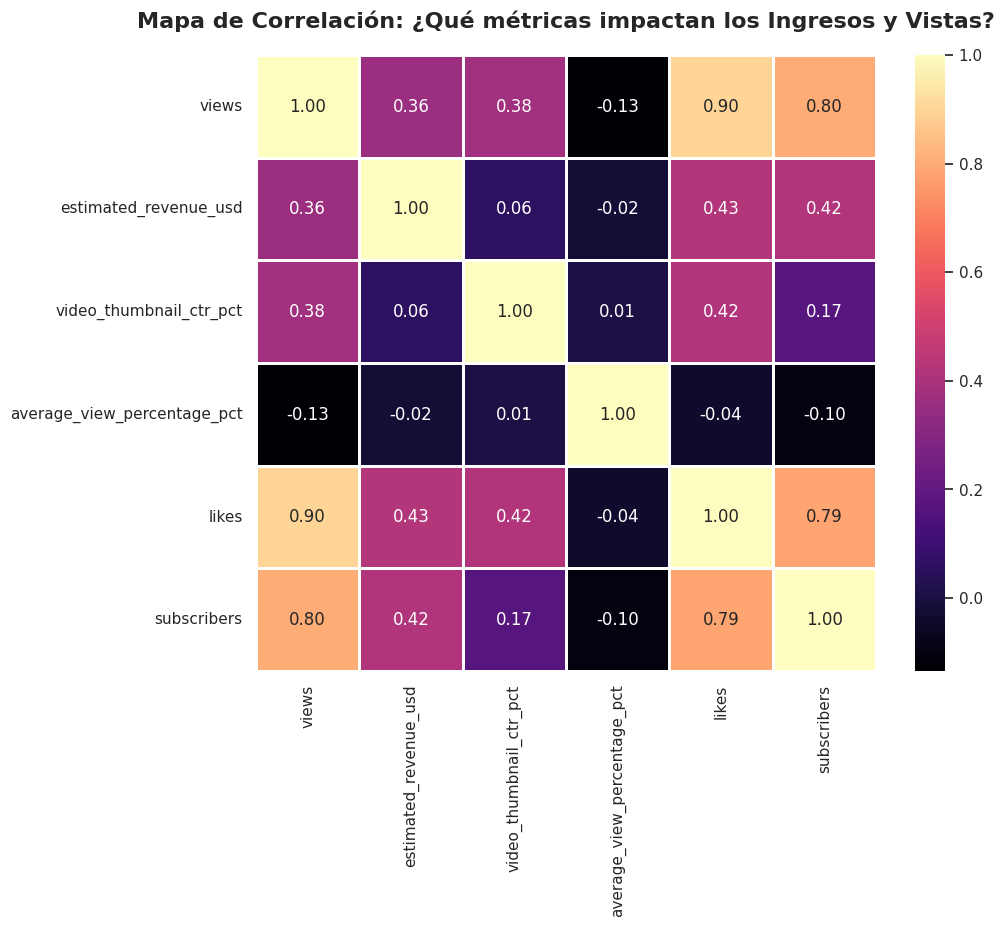

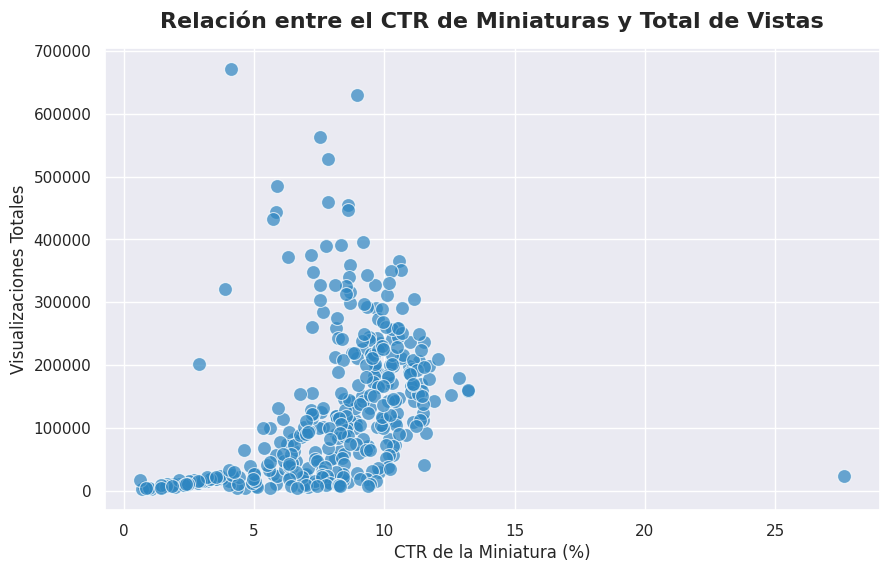

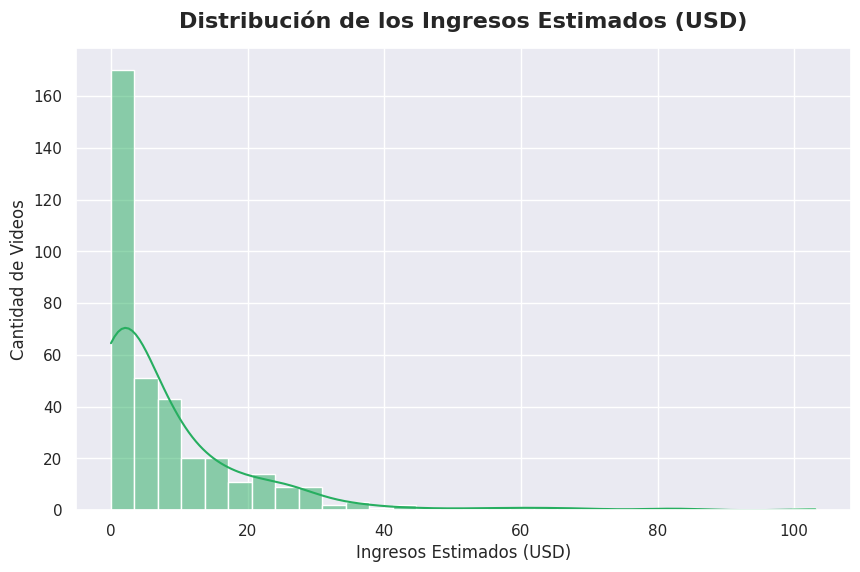


✅ ¡Gráficos generados! Guárdalos (clic derecho -> guardar imagen) para tu Canva.


In [3]:
# 3. ANÁLISIS EXPLORATORIO Y VISUALIZACIÓN (EDA)

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual moderna (ideal para presentaciones)
sns.set_theme(style="darkgrid", palette="viridis")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("=== GENERANDO GRÁFICOS PARA LA PRESENTACIÓN ===\n")

# Seleccionar solo las métricas más importantes para el negocio
cols_negocio = [
    'views',
    'estimated_revenue_usd',
    'video_thumbnail_ctr_pct',
    'average_view_percentage_pct',
    'likes',
    'subscribers'
]

# GRÁFICO 1: Mapa de Correlaciones (¿Qué variables traen dinero?)
plt.figure(figsize=(10, 8))
# Calculamos la correlación y la graficamos en un mapa de calor
sns.heatmap(df[cols_negocio].corr(), annot=True, cmap="magma", fmt=".2f", linewidths=1)
plt.title("Mapa de Correlación: ¿Qué métricas impactan los Ingresos y Vistas?", fontsize=16, fontweight='bold', pad=20)
plt.show()

# GRÁFICO 2: CTR vs Vistas (¿Un buen Thumbnail garantiza el éxito?)
plt.figure()
sns.scatterplot(data=df, x='video_thumbnail_ctr_pct', y='views', alpha=0.7, color="#2E86C1", s=100)
plt.title("Relación entre el CTR de Miniaturas y Total de Vistas", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("CTR de la Miniatura (%)")
plt.ylabel("Visualizaciones Totales")
plt.show()

# GRÁFICO 3: Distribución de Ingresos (¿Cómo se distribuye la riqueza?)
plt.figure()
sns.histplot(df['estimated_revenue_usd'], bins=30, kde=True, color="#27AE60")
plt.title("Distribución de los Ingresos Estimados (USD)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Ingresos Estimados (USD)")
plt.ylabel("Cantidad de Videos")
plt.show()

print("\n✅ ¡Gráficos generados! Guárdalos (clic derecho -> guardar imagen) para tu Canva.")